In [3]:
import zipfile
import os
zip_ref = zipfile.ZipFile('C:/Users/swani/Downloads/chest-xrays.zip', 'r')
zip_ref.extractall('C:/Users/swani/OneDrive/Desktop/Deep_learning/project')
zip_ref.close()

In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Define the root directory and paths for the combined dataset
data_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray'
combined_path = 'C:/Users/swani/OneDrive/Desktop/Deep_learning/project/chest_xray_total'

# Create a combined dataset directory
os.makedirs(combined_path, exist_ok=True)

# Combine all images from train, val, and test into a single directory for each class
for split in ['train', 'val', 'test']:
    for class_name in ['normal', 'pneumonia']:
        source_dir = os.path.join(data_path, split, class_name)
        target_dir = os.path.join(combined_path, class_name)
        os.makedirs(target_dir, exist_ok=True)
        for file_name in os.listdir(source_dir):
            source_file = os.path.join(source_dir, file_name)
            target_file = os.path.join(target_dir, file_name)
            shutil.copyfile(source_file, target_file)

In [18]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset  # Imported Subset
from sklearn.model_selection import train_test_split  # Imported train_test_split

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert images to grayscale if not already
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(size=224),
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize the images
])

# Load the combined dataset
combined_dataset = datasets.ImageFolder(combined_path, transform=transform)

# Calculate split sizes
total_size = len(combined_dataset)
train_size = int(0.7 * total_size)
valid_size = int(0.15 * total_size)
test_size = total_size - train_size - valid_size

# Split the combined dataset
indices = list(range(total_size))
np.random.seed(25)  # Ensure reproducibility
np.random.shuffle(indices)

train_indices = indices[:train_size]
valid_indices = indices[train_size:train_size + valid_size]
test_indices = indices[train_size + valid_size:]

# Create subset datasets
train_dataset = Subset(combined_dataset, train_indices)
val_dataset = Subset(combined_dataset, valid_indices)
test_dataset = Subset(combined_dataset, test_indices)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Print dataset sizes
print(f'Total samples: {total_size}')
print(f'Train samples: {train_size}')
print(f'Validation samples: {valid_size}')
print(f'Test samples: {test_size}')


Total samples: 5856
Train samples: 4099
Validation samples: 878
Test samples: 879


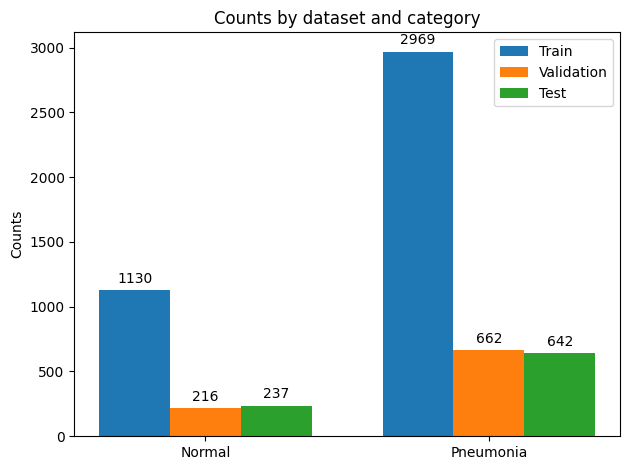

In [19]:
import matplotlib.pyplot as plt

def count_labels(dataloader):
    label_count = {'Normal': 0, 'Pneumonia': 0}
    for images, labels in dataloader:
        for label in labels:
            if label == 0:  # Assuming '0' is the label for 'Normal'
                label_count['Normal'] += 1
            else:  # Assuming '1' is the label for 'Pneumonia'
                label_count['Pneumonia'] += 1
    return label_count

# Assuming train_loader, valid_loader, and test_loader are already defined
train_counts = count_labels(train_loader)
valid_counts = count_labels(val_loader)
test_counts = count_labels(test_loader)

# Data to plot
labels = ['Normal', 'Pneumonia']
train_data = [train_counts['Normal'], train_counts['Pneumonia']]
valid_data = [valid_counts['Normal'], valid_counts['Pneumonia']]
test_data = [test_counts['Normal'], test_counts['Pneumonia']]

x = range(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x, train_data, width, label='Train')
rects2 = ax.bar([p + width for p in x], valid_data, width, label='Validation')
rects3 = ax.bar([p + width * 2 for p in x], test_data, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Counts')
ax.set_title('Counts by dataset and category')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend()

# Function to attach a text label above each bar
def autolabel(rects):
    """Attach a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()

Train Set:


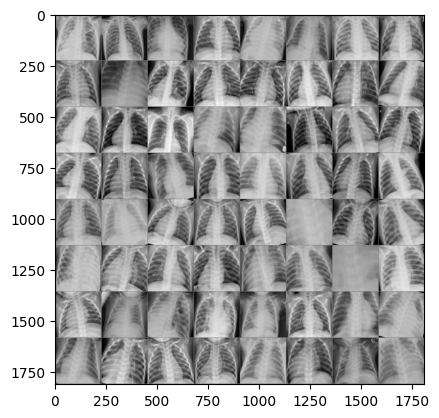

pneumonia normal pneumonia normal pneumonia pneumonia normal pneumonia normal pneumonia pneumonia normal normal pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia normal normal pneumonia normal normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal normal normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia pneumonia pneumonia
Validation Set:


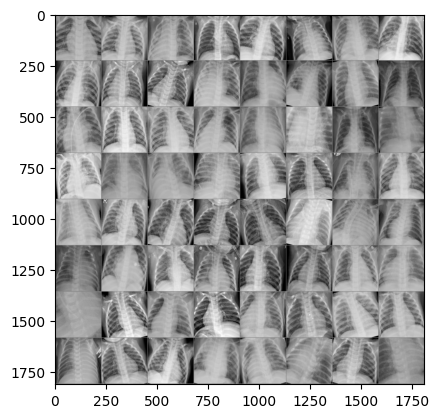

pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia normal pneumonia normal pneumonia pneumonia pneumonia normal pneumonia normal pneumonia pneumonia pneumonia pneumonia normal pneumonia
Test Set:


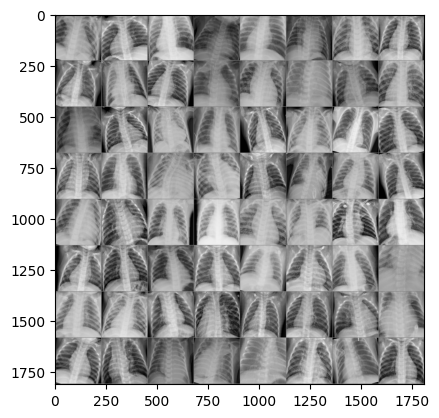

pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia normal normal normal pneumonia pneumonia pneumonia normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal normal normal normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal normal pneumonia pneumonia normal pneumonia pneumonia pneumonia pneumonia pneumonia pneumonia normal


In [20]:
import torchvision as torchvision
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Function to print and visualize data loader
def print_data_loader(data_loader, dataset_name):
    print(f'{dataset_name} Set:')
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    # Show images
    imshow(torchvision.utils.make_grid(images))
    # Print labels
    print(' '.join(f'{combined_dataset.classes[labels[j]]}' for j in range(len(labels))))

# Visualize the train loader
print_data_loader(train_loader, 'Train')

# Visualize the validation loader
print_data_loader(val_loader, 'Validation')

# Visualize the test loader
print_data_loader(test_loader, 'Test')


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import time

# Define the VGG19 model
class VGG19(nn.Module):
    def __init__(self):
        super(VGG19, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # Change input channels to 1 for grayscale
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.linear_layers = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 2)  # Change output to 2 classes
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.linear_layers(x)
        return x

# Initialize the model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
num_epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    validation_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = validation_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch + 1}/{num_epochs}] Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
    print(f'Epoch [{epoch + 1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

print('Finished Training')
elapsed_time = time.time() - start_time
print(f'Training time: {elapsed_time:.2f} seconds')

Epoch [1/10] Training Loss: 0.5789, Training Accuracy: 74.90%
Epoch [1/10] Validation Loss: 0.8024, Validation Accuracy: 37.13%
Epoch [2/10] Training Loss: 0.4508, Training Accuracy: 80.36%
Epoch [2/10] Validation Loss: 0.4493, Validation Accuracy: 81.66%
Epoch [3/10] Training Loss: 0.3235, Training Accuracy: 85.78%
Epoch [3/10] Validation Loss: 0.6289, Validation Accuracy: 74.72%
Epoch [4/10] Training Loss: 0.3074, Training Accuracy: 88.12%
Epoch [4/10] Validation Loss: 0.4511, Validation Accuracy: 82.69%
Epoch [5/10] Training Loss: 0.3067, Training Accuracy: 87.36%
Epoch [5/10] Validation Loss: 0.6519, Validation Accuracy: 81.44%
Epoch [6/10] Training Loss: 0.2719, Training Accuracy: 89.12%
Epoch [6/10] Validation Loss: 0.4425, Validation Accuracy: 81.78%
Epoch [7/10] Training Loss: 0.2528, Training Accuracy: 90.39%
Epoch [7/10] Validation Loss: 1.0294, Validation Accuracy: 75.51%
Epoch [8/10] Training Loss: 0.2627, Training Accuracy: 89.80%
Epoch [8/10] Validation Loss: 0.2261, Vali

In [23]:
# Testing phase
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
predictions, true_labels, predicted_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        predictions.extend(predicted.cpu().numpy())
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct_test / total_test
test_loss = test_loss / len(test_loader)

print(f'Test Accuracy: {test_accuracy:.2f}%')
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f'Final Precision: {precision:.4f}')
print(f'Final Recall: {recall:.4f}')
print(f'Final F1 Score: {f1:.4f}')
print(f"Training time: {elapsed_time:.2f} seconds")

Test Accuracy: 92.04%
Final Precision: 0.9256
Final Recall: 0.9204
Final F1 Score: 0.9218
Training time: 6899.79 seconds


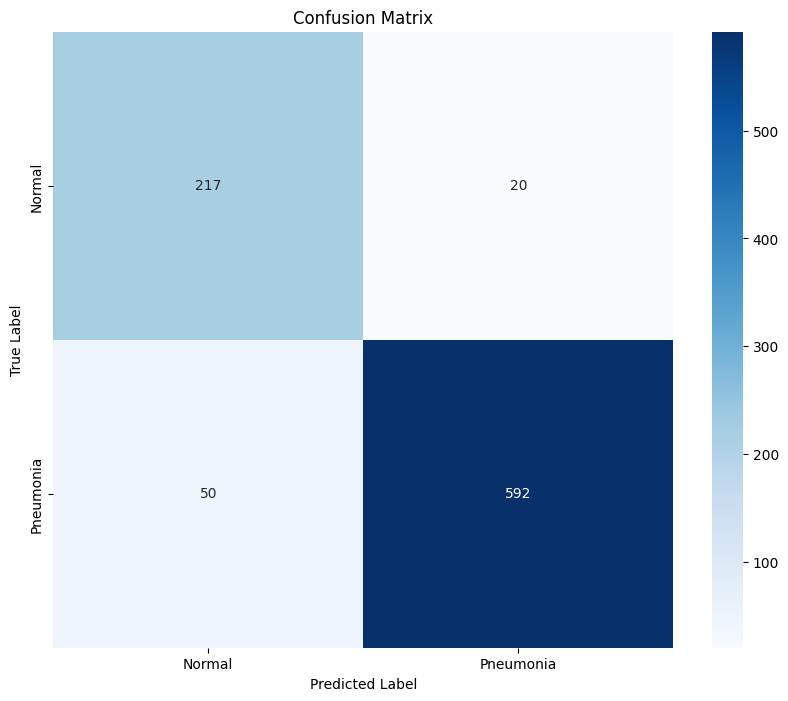

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Define class labels
class_labels = ['Normal', 'Pneumonia']

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


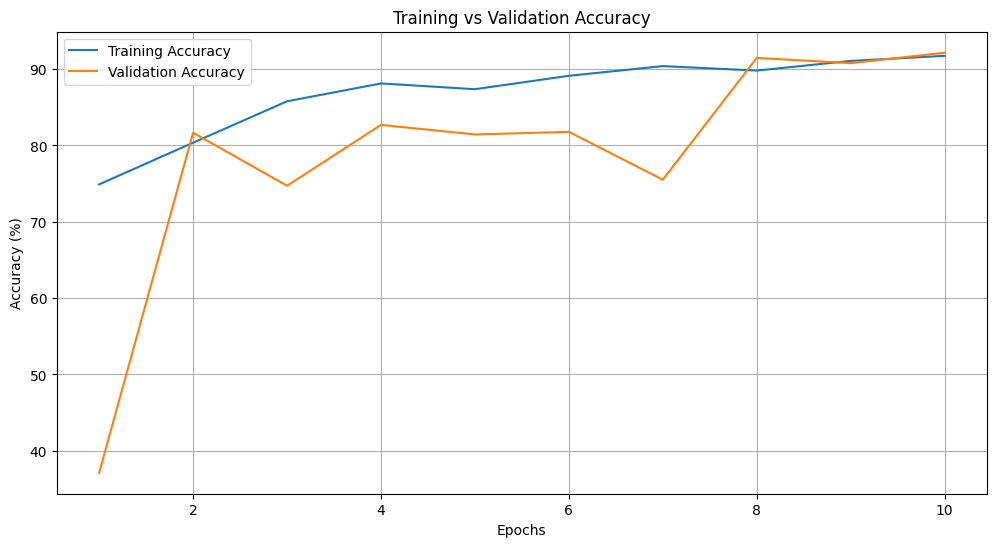

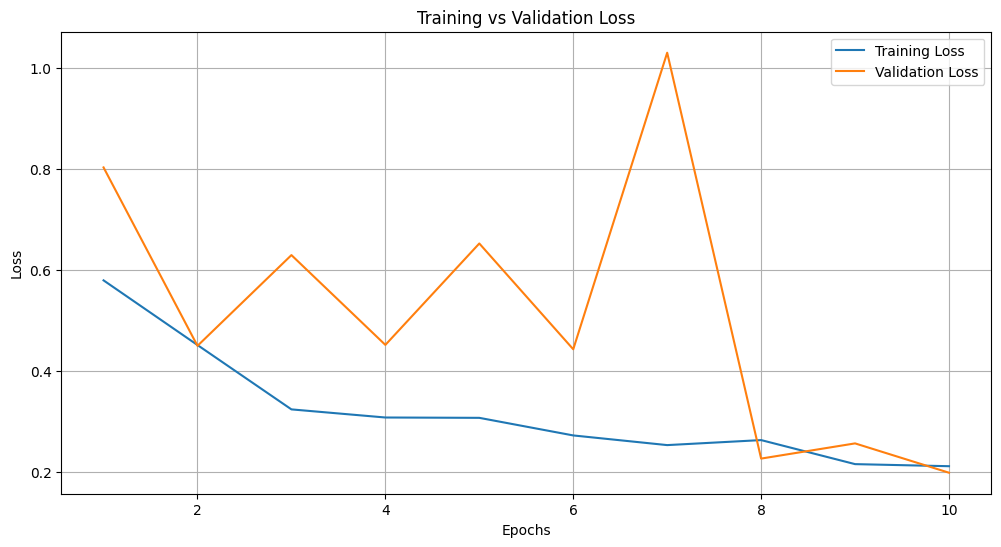

In [26]:
import matplotlib.pyplot as plt

# Plot training and validation accuracies
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs+1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


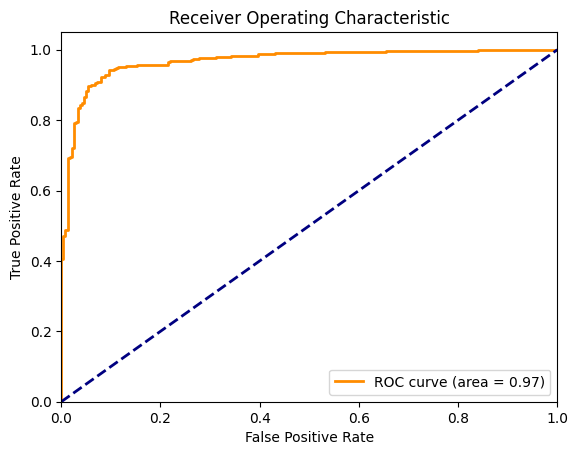

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert true_labels to binary format for ROC calculation
true_labels_binary = label_binarize(true_labels, classes=[0, 1])

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(true_labels_binary.ravel(), [prob[1] for prob in predicted_probs])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## VGG 19 with dropout layers, weight decay and early stopping

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import pickle

# Define the VGG19 model with dropout layers
class Adv_VGG19(nn.Module):
    def __init__(self):
        super(Adv_VGG19, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # Change input channels to 1 for grayscale
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.linear_layers = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 2)  # Change output to 2 classes
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.linear_layers(x)
        return x

# Initialize the model, loss function, and optimizer with L2 regularization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_adv = Adv_VGG19().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_adv.parameters(), lr=0.01, weight_decay=1e-4)  # Add L2 regularization

# Assuming train_loader and val_loader are already defined
num_epochs = 15
patience = 2
best_val_loss = float('inf')
best_model_wts = None
epochs_no_improve = 0

train_losses_adv, val_losses_adv, train_accuracies_adv, val_accuracies_adv = [], [], [], []

start_time = time.time()
for epoch in range(num_epochs):
    model_adv.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_adv(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss_adv = running_loss / len(train_loader)
    train_accuracy_adv = 100 * correct_train / total_train
    train_losses_adv.append(train_loss_adv)
    train_accuracies_adv.append(train_accuracy_adv)

    model_adv.eval()
    validation_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_adv(inputs)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss_adv = validation_loss / len(val_loader)
    val_accuracy_adv = 100 * correct_val / total_val
    val_losses_adv.append(val_loss_adv)
    val_accuracies_adv.append(val_accuracy_adv)

    print(f'Epoch [{epoch + 1}/{num_epochs}] Training Loss Adv VGG19: {train_loss_adv:.4f}, Training Accuracy Adv VGG19: {train_accuracy_adv:.2f}%')
    print(f'Epoch [{epoch + 1}/{num_epochs}] Validation Loss Adv VGG19: {val_loss_adv:.4f}, Validation Accuracy Adv VGG19: {val_accuracy_adv:.2f}%')

    # Check if this is the best model
    if val_loss_adv < best_val_loss:
        best_val_loss = val_loss_adv
        best_model_wts = model_adv.state_dict().copy()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve == patience:
        print(f'Early stopping at epoch {epoch + 1}')
        break

print('Finished Training')
elapsed_time = time.time() - start_time
print(f'Training time: {elapsed_time:.2f} seconds')

# Load the best model weights
model_adv.load_state_dict(best_model_wts)

# Save the best model as a .pkl file
with open('best_model_adv_vgg19.pkl', 'wb') as f:
    pickle.dump(model_adv.state_dict(), f)
print(f'Saved the best model with validation loss: {best_val_loss:.4f}')


Epoch [1/15] Training Loss Adv VGG19: 0.6201, Training Accuracy Adv VGG19: 71.72%
Epoch [1/15] Validation Loss Adv VGG19: 0.5486, Validation Accuracy Adv VGG19: 85.65%
Epoch [2/15] Training Loss Adv VGG19: 0.4805, Training Accuracy Adv VGG19: 78.97%
Epoch [2/15] Validation Loss Adv VGG19: 0.6058, Validation Accuracy Adv VGG19: 75.74%
Epoch [3/15] Training Loss Adv VGG19: 0.3696, Training Accuracy Adv VGG19: 84.09%
Epoch [3/15] Validation Loss Adv VGG19: 0.3536, Validation Accuracy Adv VGG19: 84.62%
Epoch [4/15] Training Loss Adv VGG19: 0.2974, Training Accuracy Adv VGG19: 87.12%
Epoch [4/15] Validation Loss Adv VGG19: 0.3459, Validation Accuracy Adv VGG19: 87.02%
Epoch [5/15] Training Loss Adv VGG19: 0.2935, Training Accuracy Adv VGG19: 87.92%
Epoch [5/15] Validation Loss Adv VGG19: 1.3452, Validation Accuracy Adv VGG19: 75.40%
Epoch [6/15] Training Loss Adv VGG19: 0.3518, Training Accuracy Adv VGG19: 86.63%
Epoch [6/15] Validation Loss Adv VGG19: 0.5988, Validation Accuracy Adv VGG19:

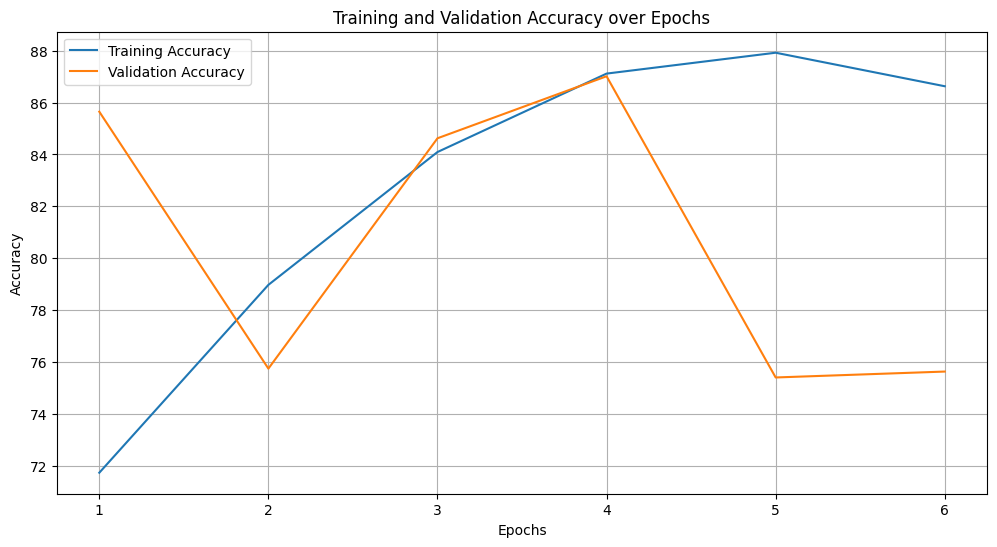

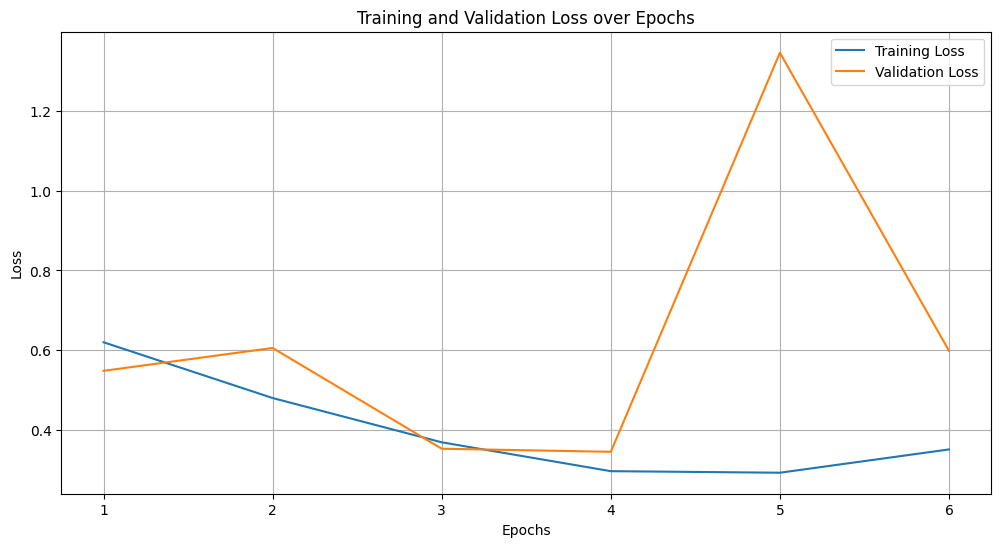

In [35]:
import matplotlib.pyplot as plt

# Determine the actual number of epochs run
actual_epochs = len(train_accuracies_adv)

# Plot training and validation accuracies
plt.figure(figsize=(12, 6))
plt.plot(range(1, actual_epochs + 1), train_accuracies_adv, label='Training Accuracy')
plt.plot(range(1, actual_epochs + 1), val_accuracies_adv, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(range(1, actual_epochs + 1), train_losses_adv, label='Training Loss')
plt.plot(range(1, actual_epochs + 1), val_losses_adv, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [42]:
# Load the best model weights
model_adv.load_state_dict(best_model_wts)

# Testing phase
model_adv.eval()
test_loss_adv = 0.0
correct_test = 0
total_test = 0
predictions, true_labels, predicted_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_adv(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        predictions.extend(predicted.cpu().numpy())
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

test_accuracy_adv = 100 * correct_test / total_test
test_loss_adv = test_loss / len(test_loader)

print(f'Test Accuracy: {test_accuracy_adv:.2f}%')
print(f'Test Loss: {test_loss_adv:.2f}')
precision_adv = precision_score(true_labels, predictions, average='weighted')
recall_adv = recall_score(true_labels, predictions, average='weighted')
f1_adv = f1_score(true_labels, predictions, average='weighted')

print(f'Final Precision: {precision:.4f}')
print(f'Final Recall: {recall:.4f}')
print(f'Final F1 Score: {f1:.4f}')

Test Accuracy: 75.88%
Test Loss: 1.88
Final Precision: 0.9256
Final Recall: 0.9204
Final F1 Score: 0.9218


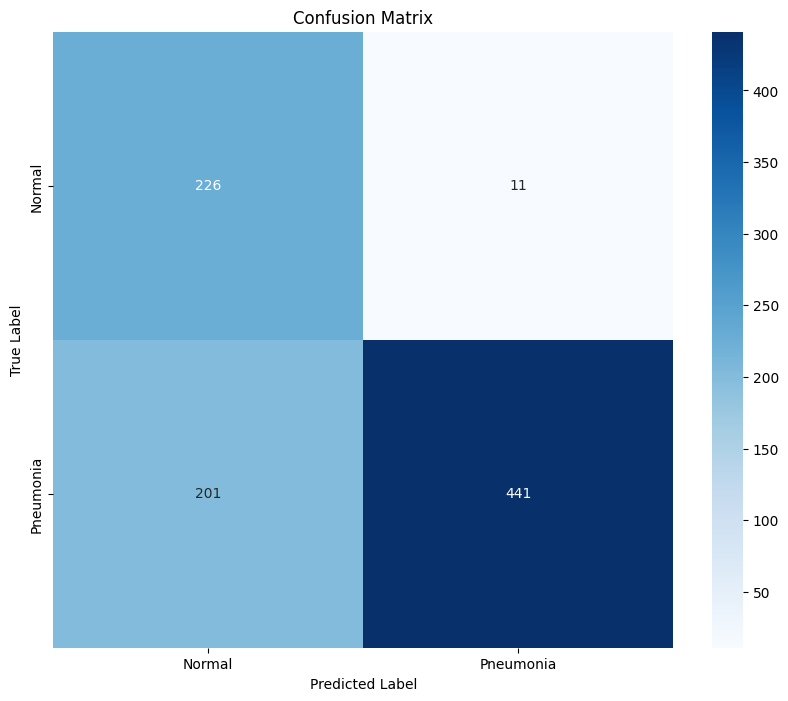

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Define class labels
class_labels = ['Normal', 'Pneumonia']

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


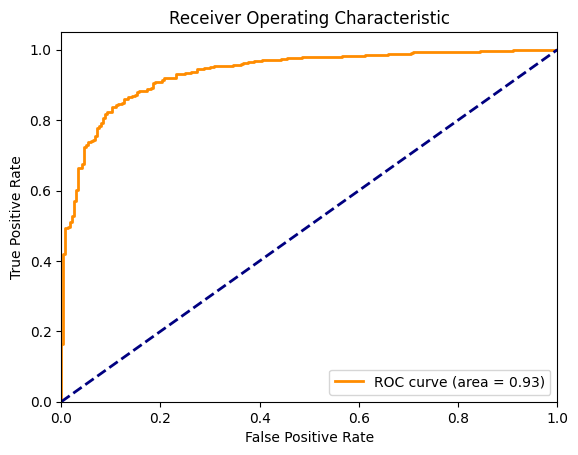

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert true_labels to binary format for ROC calculation
true_labels_binary = label_binarize(true_labels, classes=[0, 1])

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(true_labels_binary.ravel(), [prob[1] for prob in predicted_probs])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

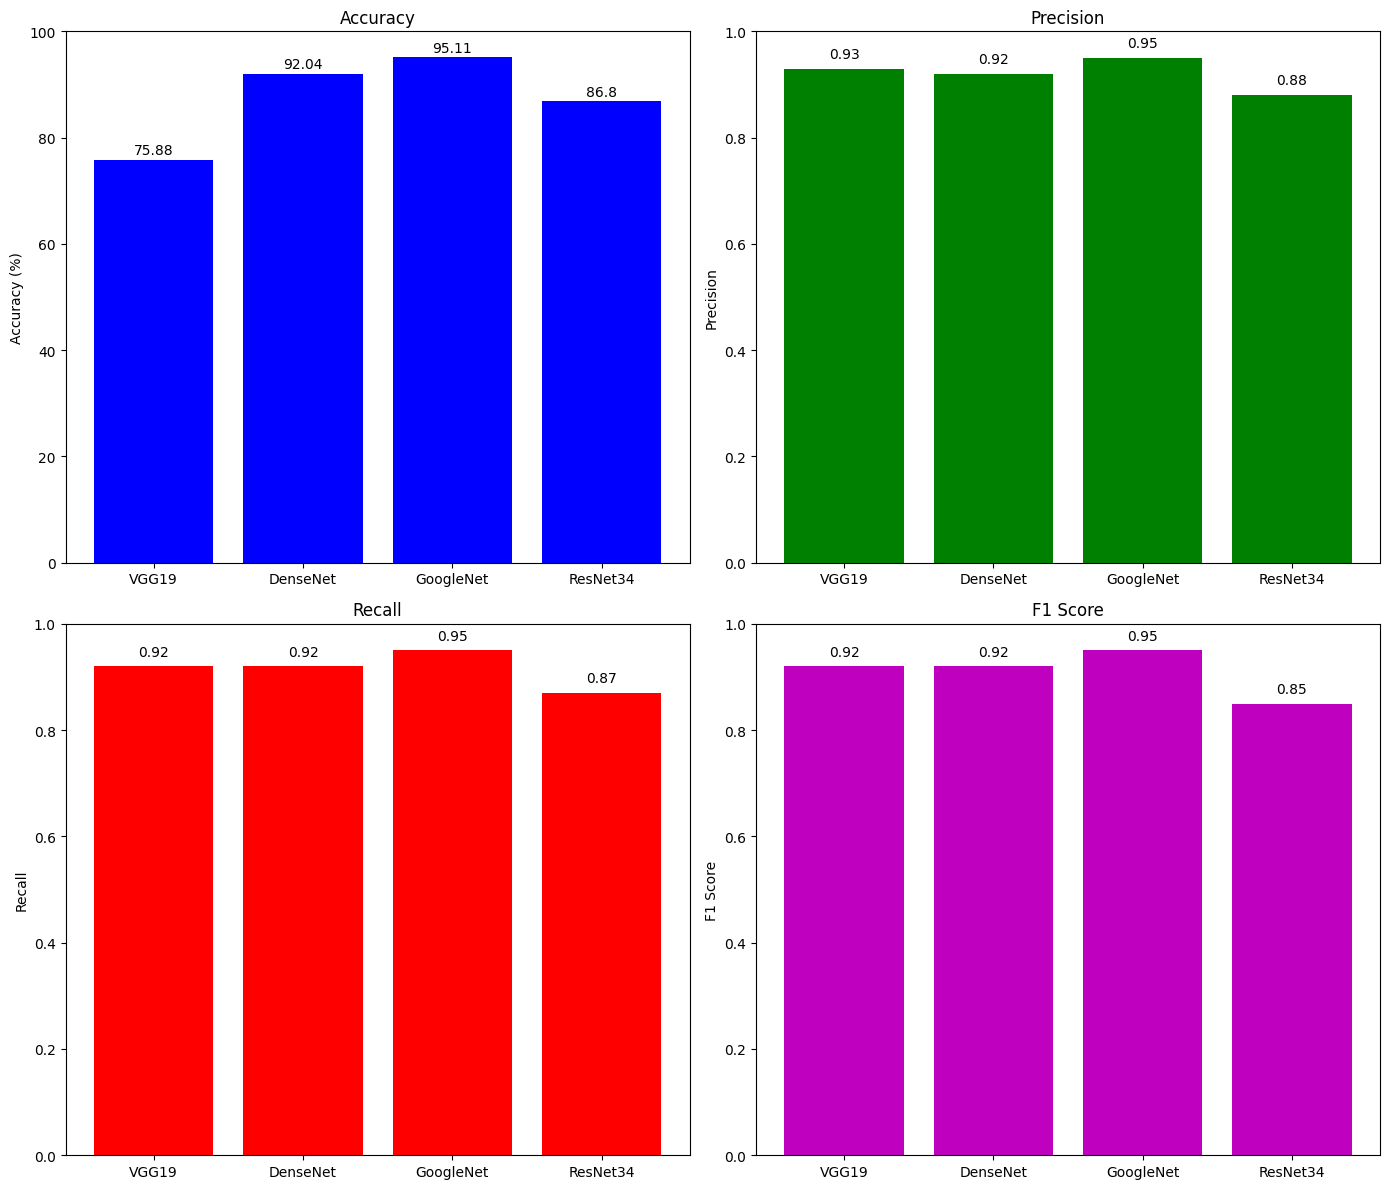

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
models = ['VGG19', 'DenseNet', 'GoogleNet', 'ResNet34']
accuracy = [75.88, 92.04, 95.11, 86.80]
precision = [0.93, 0.92, 0.95, 0.88]
recall = [0.92, 0.92, 0.95, 0.87]
f1_score = [0.92, 0.92, 0.95, 0.85]

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Accuracy plot
axs[0, 0].bar(models, accuracy, color='b')
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Accuracy (%)')
axs[0, 0].set_ylim(0, 100)
for i, v in enumerate(accuracy):
    axs[0, 0].text(i, v + 1, str(v), ha='center')

# Precision plot
axs[0, 1].bar(models, precision, color='g')
axs[0, 1].set_title('Precision')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_ylim(0, 1)
for i, v in enumerate(precision):
    axs[0, 1].text(i, v + 0.02, str(v), ha='center')

# Recall plot
axs[1, 0].bar(models, recall, color='r')
axs[1, 0].set_title('Recall')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_ylim(0, 1)
for i, v in enumerate(recall):
    axs[1, 0].text(i, v + 0.02, str(v), ha='center')

# F1 Score plot
axs[1, 1].bar(models, f1_score, color='m')
axs[1, 1].set_title('F1 Score')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_ylim(0, 1)
for i, v in enumerate(f1_score):
    axs[1, 1].text(i, v + 0.02, str(v), ha='center')

# Adjust layout
plt.tight_layout()
plt.show()
